In [22]:
!pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# F1 Analysis 1950–2024

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Pandas версия:', pd.__version__)

Pandas версия: 3.0.2


## 1. Загрузка данных

In [25]:
drivers      = pd.read_csv('drivers.csv')
results      = pd.read_csv('results.csv')
races        = pd.read_csv('races.csv')
constructors = pd.read_csv('constructors.csv')
circuits     = pd.read_csv('circuits.csv')
standings    = pd.read_csv('driver_standings.csv')

print('Гонки:',    races.shape)
print('Пилоты:',   drivers.shape)
print('Результаты:', results.shape)
print('Кольца', circuits.shape)

Гонки: (1125, 18)
Пилоты: (861, 9)
Результаты: (26759, 18)
Кольца (77, 9)


## 2. Топ-10 пилотов по победам за всю историю

C:\Users\mzhuc\AppData\Local\Temp\ipykernel_8776\3947047033.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_winners.values, y=top_winners.index, palette='Reds_r')


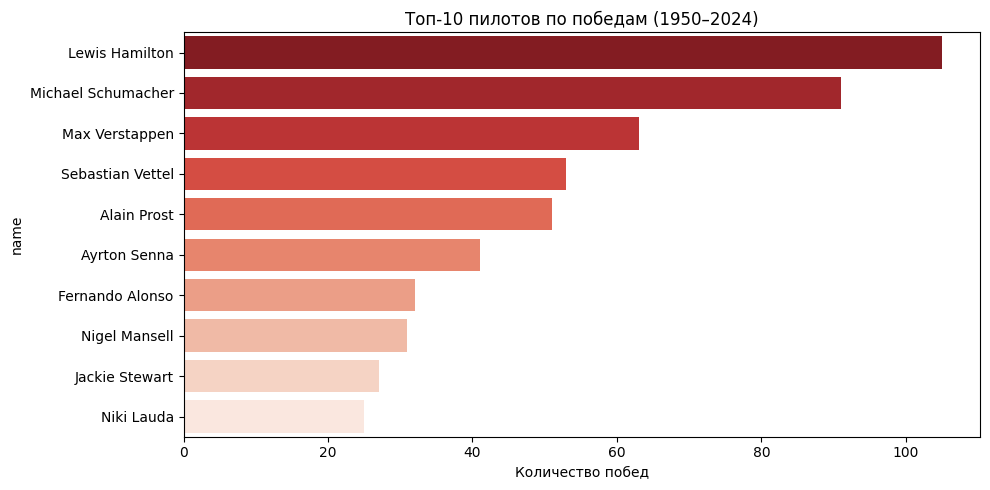

In [26]:
wins = results[results['positionOrder'] == 1]
wins = wins.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
wins['name'] = wins['forename'] + ' ' + wins['surname']

top_winners = wins.groupby('name').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_winners.values, y=top_winners.index, palette='Reds_r')
plt.title('Топ-10 пилотов по победам (1950–2024)')
plt.xlabel('Количество побед')
plt.tight_layout()
plt.show()

## 3. Победы по сезонам (динамика)

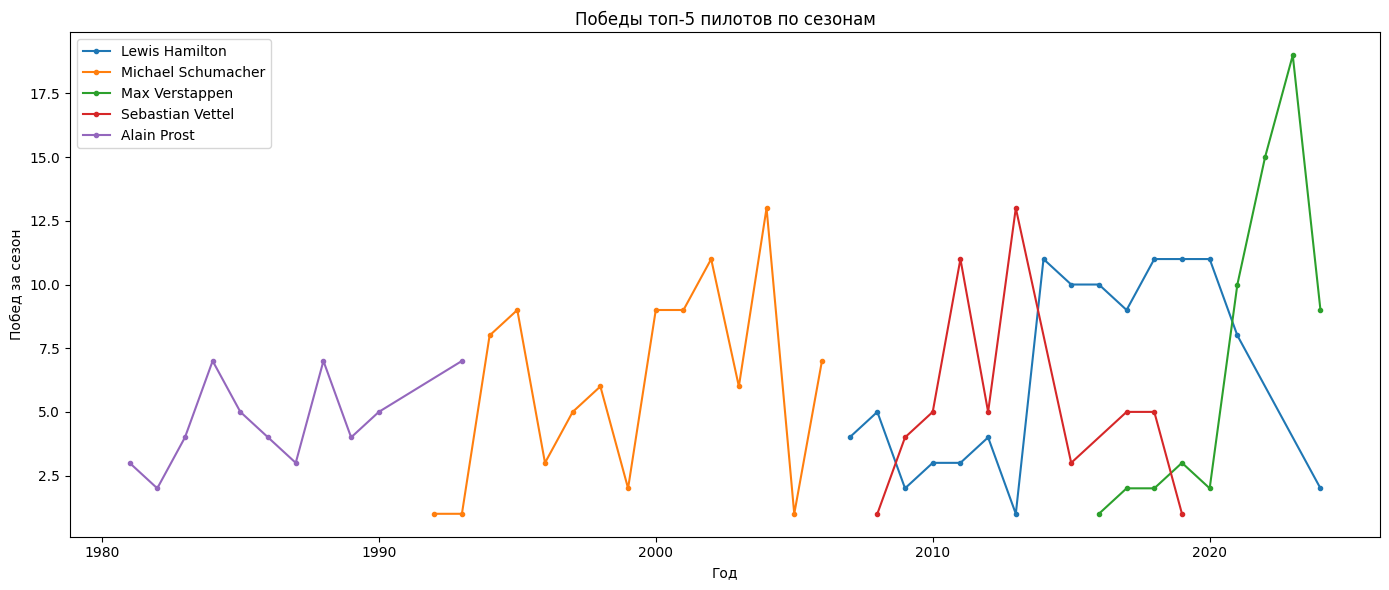

In [8]:
wins_year = wins.merge(races[['raceId', 'year']], on='raceId')
wins_per_year = wins_year.groupby(['year', 'name']).size().reset_index(name='wins')

# Топ-5 пилотов по всем победам
top5 = top_winners.head(5).index.tolist()
filtered = wins_per_year[wins_per_year['name'].isin(top5)]

plt.figure(figsize=(14, 6))
for name in top5:
    d = filtered[filtered['name'] == name]
    plt.plot(d['year'], d['wins'], label=name, marker='o', markersize=3)

plt.title('Победы топ-5 пилотов по сезонам')
plt.xlabel('Год')
plt.ylabel('Побед за сезон')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Топ-10 команд по победам

C:\Users\mzhuc\AppData\Local\Temp\ipykernel_8776\4106783330.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_teams.values, y=top_teams.index, palette='Blues_r')


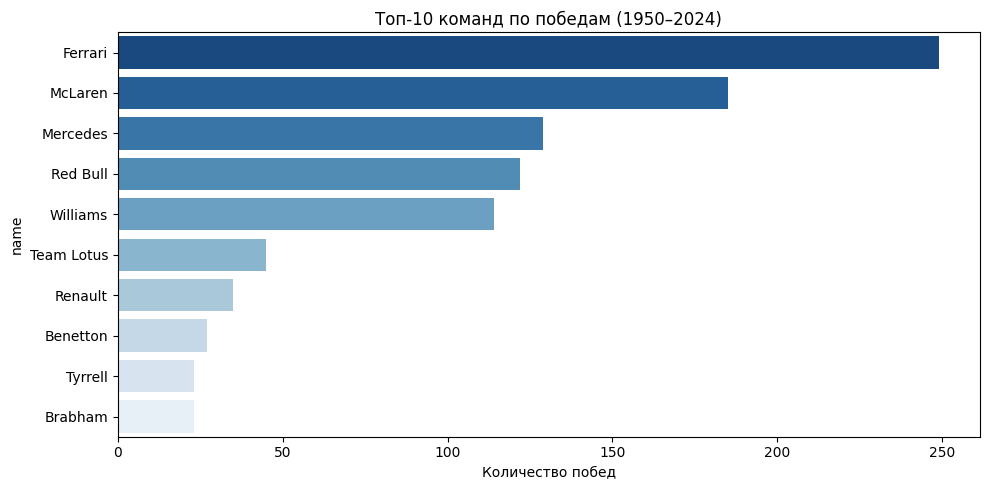

In [12]:
con_wins = results[results['positionOrder'] == 1]
con_wins = con_wins.merge(constructors[['constructorId', 'name']], on='constructorId')

top_teams = con_wins.groupby('name').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_teams.values, y=top_teams.index, palette='Blues_r')
plt.title('Топ-10 команд по победам (1950–2024)')
plt.xlabel('Количество побед')
plt.tight_layout()
plt.show()

## 5. Трассы с наибольшим числом гонок

C:\Users\mzhuc\AppData\Local\Temp\ipykernel_8776\1427414143.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='races', y='label', data=top_circuits, palette='Greens_r')


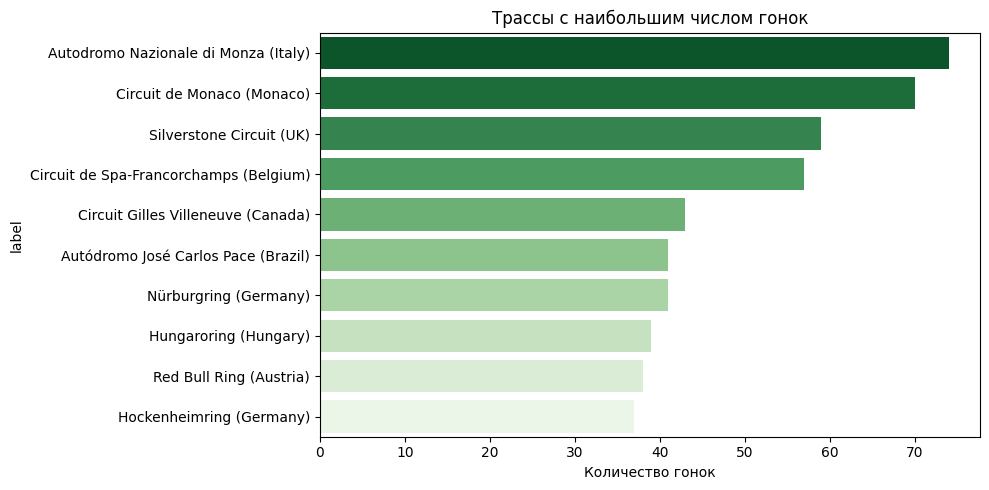

In [16]:
circuits_renamed = circuits[['circuitId', 'name', 'country']].rename(columns={'name': 'circuit_name'})
races_circuits = races.merge(circuits_renamed, on='circuitId')
top_circuits = races_circuits.groupby(['circuit_name', 'country']).size().sort_values(ascending=False).head(10)
top_circuits = top_circuits.reset_index(name='races')
top_circuits['label'] = top_circuits['circuit_name'] + ' (' + top_circuits['country'] + ')'

plt.figure(figsize=(10, 5))
sns.barplot(x='races', y='label', data=top_circuits, palette='Greens_r')
plt.title('Трассы с наибольшим числом гонок')
plt.xlabel('Количество гонок')
plt.tight_layout()
plt.show()

---
## 6. SQL — загружаем данные в базу SQLite

In [17]:
import sqlite3

# Создаём файл базы данных (если не существует — создастся автоматически)
conn = sqlite3.connect('f1.db')

# Загружаем CSV таблицы в базу данных
# pandas умеет писать DataFrame прямо в SQL таблицу
drivers.to_sql('drivers', conn, if_exists='replace', index=False)
results.to_sql('results', conn, if_exists='replace', index=False)
races.to_sql('races', conn, if_exists='replace', index=False)
constructors.to_sql('constructors', conn, if_exists='replace', index=False)
circuits.to_sql('circuits', conn, if_exists='replace', index=False)
standings.to_sql('standings', conn, if_exists='replace', index=False)

print('База данных f1.db создана')
print('Таблицы загружены: drivers, results, races, constructors, circuits, standings')

База данных f1.db создана
Таблицы загружены: drivers, results, races, constructors, circuits, standings


### Запрос 1 — Топ-10 пилотов по победам (чистый SQL)

In [18]:
query = """
SELECT
    d.forename || ' ' || d.surname AS driver,
    d.nationality,
    COUNT(*) AS wins
FROM results r
JOIN drivers d ON r.driverId = d.driverId
WHERE r.positionOrder = 1
GROUP BY d.driverId
ORDER BY wins DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,driver,nationality,wins
0,Lewis Hamilton,British,105
1,Michael Schumacher,German,91
2,Max Verstappen,Dutch,63
3,Sebastian Vettel,German,53
4,Alain Prost,French,51
5,Ayrton Senna,Brazilian,41
6,Fernando Alonso,Spanish,32
7,Nigel Mansell,British,31
8,Jackie Stewart,British,27
9,Jim Clark,British,25


### Запрос 2 — Сколько гонок провёл каждый пилот и его средняя позиция финиша

In [19]:
query = """
SELECT
    d.forename || ' ' || d.surname AS driver,
    COUNT(*) AS races,
    SUM(CASE WHEN r.positionOrder = 1 THEN 1 ELSE 0 END) AS wins,
    ROUND(AVG(r.positionOrder), 1) AS avg_finish
FROM results r
JOIN drivers d ON r.driverId = d.driverId
GROUP BY d.driverId
HAVING races > 100
ORDER BY wins DESC
LIMIT 15
"""

pd.read_sql(query, conn)

,driver,races,wins,avg_finish
0,Lewis Hamilton,356,105,5.0
1,Michael Schumacher,308,91,6.9
2,Max Verstappen,209,63,5.6
3,Sebastian Vettel,300,53,7.1
4,Alain Prost,202,51,7.5
5,Ayrton Senna,162,41,8.3
6,Fernando Alonso,404,32,8.5
7,Nigel Mansell,192,31,11.2
8,Niki Lauda,174,25,10.9
9,Nelson Piquet,207,23,10.0


### Запрос 3 — Победы команд по десятилетиям

In [20]:
query = """
SELECT
    (ra.year / 10) * 10 AS decade,
    c.name AS team,
    COUNT(*) AS wins
FROM results r
JOIN races ra ON r.raceId = ra.raceId
JOIN constructors c ON r.constructorId = c.constructorId
WHERE r.positionOrder = 1
GROUP BY decade, c.constructorId
ORDER BY decade, wins DESC
"""

df_decades = pd.read_sql(query, conn)

# Берём топ-3 команды каждого десятилетия
top3 = df_decades.groupby('decade').head(3)
print(top3.to_string(index=False))

 decade         team  wins
   1950      Ferrari    30
   1950   Alfa Romeo    11
   1950      Vanwall    10
   1960 Lotus-Climax    22
   1960      Ferrari    13
   1960          BRM    12
   1970      Ferrari    37
   1970   Team Lotus    35
   1970      Tyrrell    21
   1980      McLaren    56
   1980     Williams    37
   1980      Ferrari    18
   1990     Williams    61
   1990      McLaren    43
   1990      Ferrari    28
   2000      Ferrari    85
   2000      McLaren    41
   2000      Renault    20
   2010     Mercedes    93
   2010     Red Bull    56
   2010      Ferrari    28
   2020     Red Bull    60
   2020     Mercedes    27
   2020      Ferrari    10


### Запрос 4 — Поиск конкретного пилота (попробуй изменить имя)

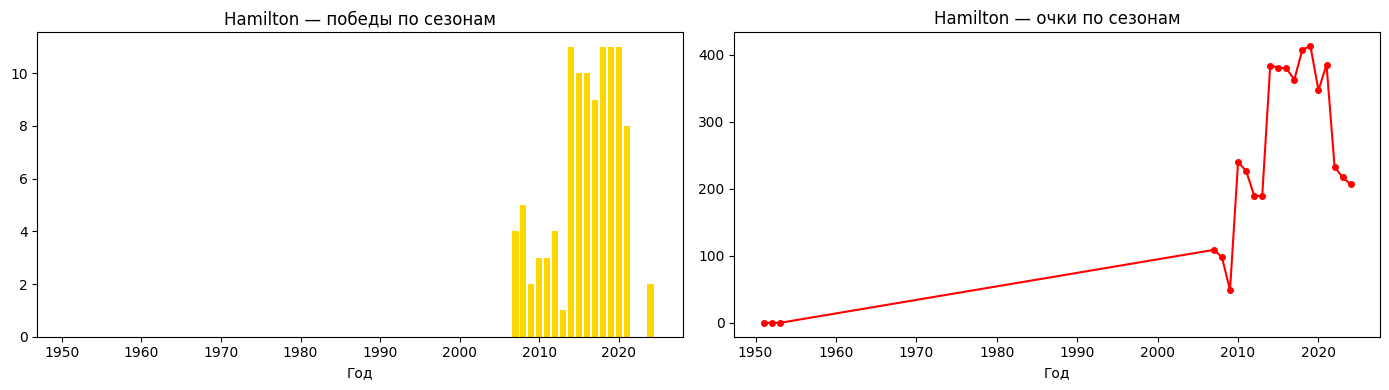

 year  races  wins  podiums  total_points
 1951      2     0        0           0.0
 1952      2     0        0           0.0
 1953      1     0        0           0.0
 2007     17     4       12         109.0
 2008     18     5       10          98.0
 2009     17     2        5          49.0
 2010     19     3        9         240.0
 2011     19     3        6         227.0
 2012     20     4        7         190.0
 2013     19     1        5         189.0
 2014     19    11       16         384.0
 2015     19    10       17         381.0
 2016     21    10       17         380.0
 2017     20     9       13         363.0
 2018     21    11       17         408.0
 2019     21    11       17         413.0
 2020     16    11       14         347.0
 2021     22     8       17         385.5
 2022     22     0        9         233.0
 2023     22     0        6         217.0
 2024     24     2        5         207.0


In [21]:
# Попробуй поменять 'Hamilton' на другую фамилию: Verstappen, Schumacher, Senna
DRIVER = 'Hamilton'

query = f"""
SELECT
    ra.year,
    COUNT(*) AS races,
    SUM(CASE WHEN r.positionOrder = 1 THEN 1 ELSE 0 END) AS wins,
    SUM(CASE WHEN r.positionOrder <= 3 THEN 1 ELSE 0 END) AS podiums,
    SUM(r.points) AS total_points
FROM results r
JOIN races ra ON r.raceId = ra.raceId
JOIN drivers d ON r.driverId = d.driverId
WHERE d.surname = '{DRIVER}'
GROUP BY ra.year
ORDER BY ra.year
"""

df_driver = pd.read_sql(query, conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(df_driver['year'], df_driver['wins'], color='gold')
axes[0].set_title(f'{DRIVER} — победы по сезонам')
axes[0].set_xlabel('Год')

axes[1].plot(df_driver['year'], df_driver['total_points'], color='red', marker='o', markersize=4)
axes[1].set_title(f'{DRIVER} — очки по сезонам')
axes[1].set_xlabel('Год')

plt.tight_layout()
plt.show()

print(df_driver.to_string(index=False))